# From Logistic Regression to Neural Networks
### California Housing — Binary Classification

This notebook follows the lecture structure:
1. **Part 1** — Logistic regression: sigmoid, decision boundary, binary cross-entropy
2. **Part 2** — California housing as classification: train, evaluate, ROC
3. **Part 3** — Introduction to neural networks: one hidden layer, activations, forward pass
4. **Part 4** — Training neural networks: backpropagation, gradient descent, deeper architectures

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

---
## Part 1 — Logistic Regression

### 1.1 The sigmoid function

Linear regression outputs any real number. To turn that into a probability we apply the **sigmoid** (logistic) function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

It maps any $z \in (-\infty, +\infty)$ to the interval $(0, 1)$.

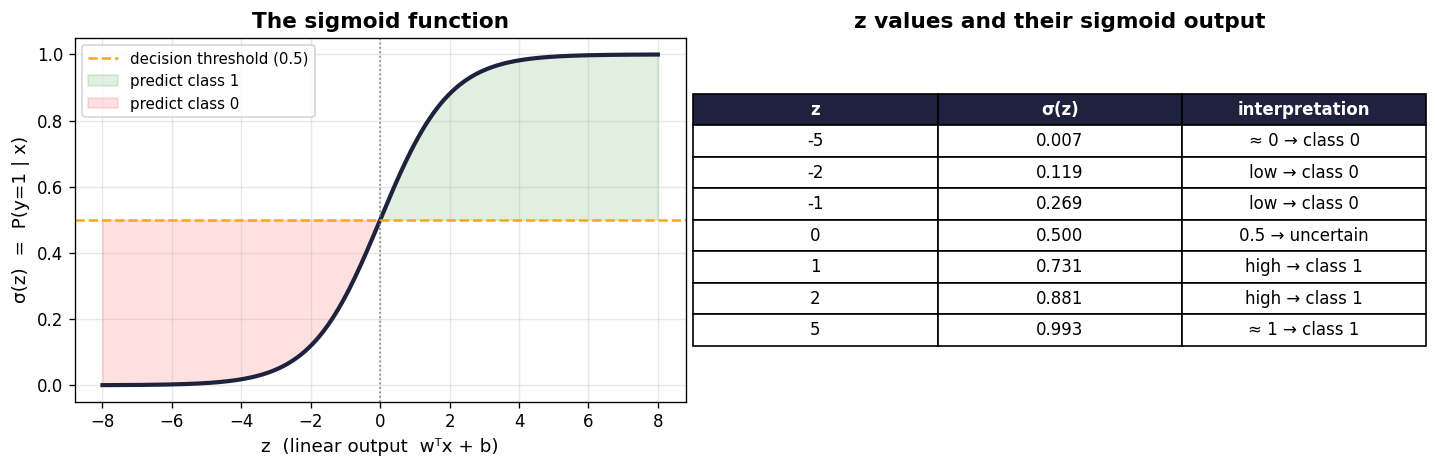

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: sigmoid curve
ax = axes[0]
ax.plot(z, sigmoid(z), color='#1E223D', linewidth=2.5)
ax.axhline(0.5, color='#F5A623', linestyle='--', linewidth=1.5, label='decision threshold (0.5)')
ax.axvline(0,   color='gray',    linestyle=':',  linewidth=1)
ax.fill_between(z, sigmoid(z), 0.5, where=(sigmoid(z) > 0.5), alpha=0.12, color='green', label='predict class 1')
ax.fill_between(z, sigmoid(z), 0.5, where=(sigmoid(z) < 0.5), alpha=0.12, color='red',   label='predict class 0')
ax.set_xlabel('z  (linear output  wᵀx + b)', fontsize=11)
ax.set_ylabel('σ(z)  =  P(y=1 | x)', fontsize=11)
ax.set_title('The sigmoid function', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: table — z → σ(z) → interpretation
ax2 = axes[1]
ax2.axis('off')
z_vals = [-5, -2, -1, 0, 1, 2, 5]
sig_vals = [f'{sigmoid(v):.3f}' for v in z_vals]
interp = ['≈ 0 → class 0', 'low → class 0', 'low → class 0',
          '0.5 → uncertain', 'high → class 1', 'high → class 1', '≈ 1 → class 1']
table = ax2.table(
    cellText=[[str(z), s, i] for z, s, i in zip(z_vals, sig_vals, interp)],
    colLabels=['z', 'σ(z)', 'interpretation'],
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1E223D')
        cell.set_text_props(color='white', fontweight='bold')
ax2.set_title('z values and their sigmoid output', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.2 The decision boundary

We predict **class 1** when $\sigma(z) \geq 0.5$, which means $z \geq 0$:

$$w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b = 0$$

In 2D this is a **line**. In higher dimensions it is a **hyperplane**. Logistic regression can only learn a **linear** boundary.

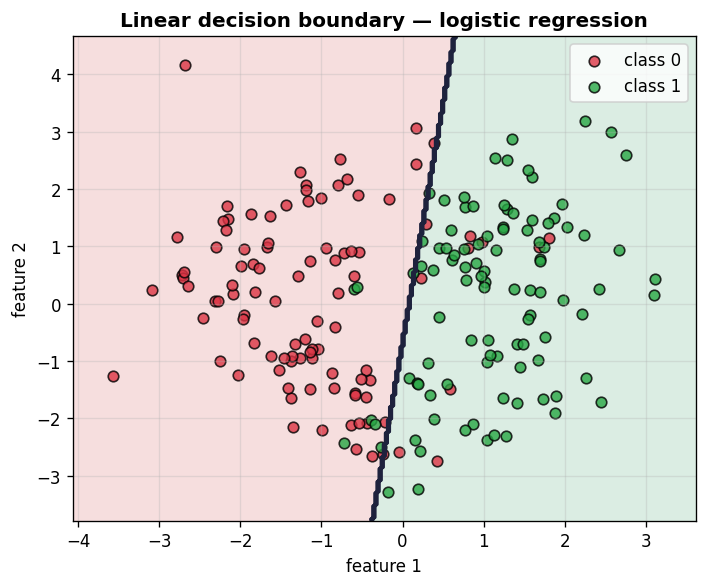

Decision boundary: 2.435·x₁ + -0.292·x₂ + -0.199 = 0


In [5]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# 2D toy dataset — linearly separable
X2, y2 = make_classification(n_samples=200, n_features=2, n_redundant=0,
                              n_informative=2, random_state=42, class_sep=1.2)

lr2d = LogisticRegression()
lr2d.fit(X2, y2)

xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-0.5, X2[:,0].max()+0.5, 300),
                     np.linspace(X2[:,1].min()-0.5, X2[:,1].max()+0.5, 300))
Z = lr2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, alpha=0.15, cmap='RdYlGn')
ax.contour(xx, yy, Z, colors='#1E223D', linewidths=2)
ax.scatter(X2[y2==0, 0], X2[y2==0, 1], c='#dc3545', edgecolors='k', s=40, label='class 0', alpha=0.8)
ax.scatter(X2[y2==1, 0], X2[y2==1, 1], c='#28a745', edgecolors='k', s=40, label='class 1', alpha=0.8)
ax.set_title('Linear decision boundary — logistic regression', fontsize=12, fontweight='bold')
ax.set_xlabel('feature 1'); ax.set_ylabel('feature 2')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Decision boundary: {lr2d.coef_[0][0]:.3f}·x₁ + {lr2d.coef_[0][1]:.3f}·x₂ + {lr2d.intercept_[0]:.3f} = 0')

### 1.3 Binary cross-entropy loss

We train by minimising **binary cross-entropy** (log loss):

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

Unlike MSE, the gradient stays large even when the model is confidently wrong.

---
## Part 2 — California Housing as Classification

### 2.1 Load data and create binary target

The original target is median house value in units of \$100k.  
We define: **expensive = median value > \$250k** (`MedHouseVal > 2.5`).

Class distribution:
  0 (≤$250k): 14,858  (72.0%)
  1 (>$250k): 5,782  (28.0%)

Total samples: 20,640

→ Imbalanced: 72% vs 28% — accuracy alone will be misleading


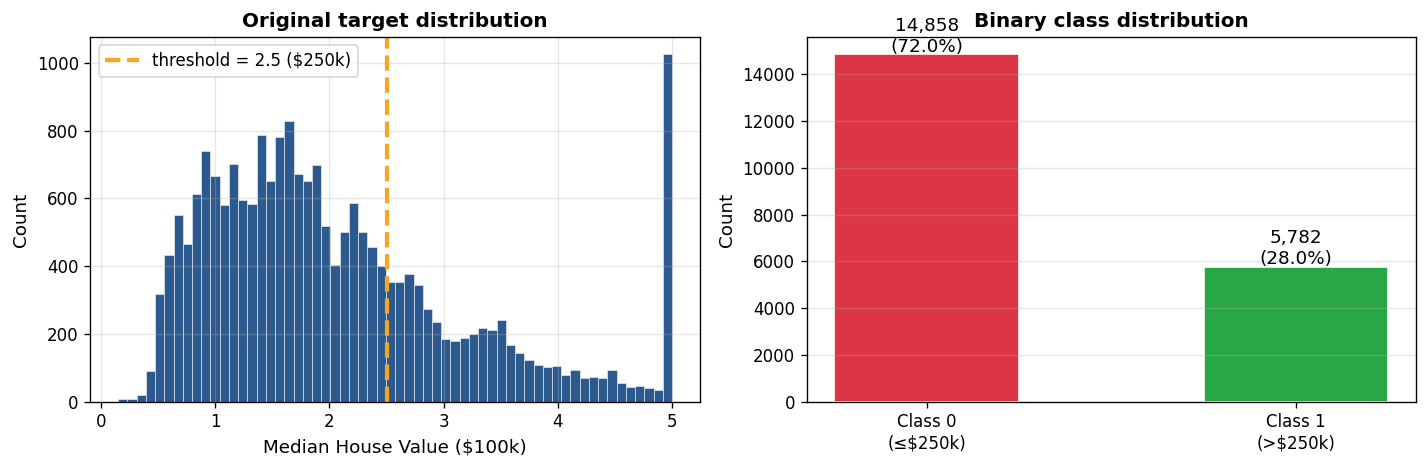

In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

# Binary target
df['expensive'] = (df['MedHouseVal'] > 2.5).astype(int)

counts = df['expensive'].value_counts()
print('Class distribution:')
print(f'  0 (≤$250k): {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)')
print(f'  1 (>$250k): {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)')
print(f'\nTotal samples: {len(df):,}')
print('\n→ Imbalanced: 72% vs 28% — accuracy alone will be misleading')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original distribution
axes[0].hist(df['MedHouseVal'], bins=60, color='#2d5a8e', edgecolor='white', linewidth=0.3)
axes[0].axvline(2.5, color='#F5A623', linewidth=2.5, linestyle='--', label='threshold = 2.5 ($250k)')
axes[0].set_xlabel('Median House Value ($100k)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Original target distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# Class bar chart
bars = axes[1].bar(['Class 0\n(≤$250k)', 'Class 1\n(>$250k)'],
                   [counts[0], counts[1]],
                   color=['#dc3545', '#28a745'], edgecolor='white', width=0.5)
for bar, cnt in zip(bars, [counts[0], counts[1]]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{cnt:,}\n({cnt/len(df)*100:.1f}%)', ha='center', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Binary class distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 2.2 Train/test split and feature scaling

In [7]:
feature_names = data.feature_names
X = df[feature_names]
y = df['expensive']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape[0]:,} samples')
print(f'Test:  {X_test_s.shape[0]:,} samples')
print(f'Features: {X_train_s.shape[1]}')
print(f'\nFeatures: {feature_names}')

Train: 16,512 samples
Test:  4,128 samples
Features: 8

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### 2.3 Train logistic regression

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

y_pred = lr.predict(X_test_s)
y_prob = lr.predict_proba(X_test_s)[:, 1]

print('Training complete.')
print(f'Test accuracy: {lr.score(X_test_s, y_test):.4f}')

Training complete.
Test accuracy: 0.8525


### 2.4 Evaluation: confusion matrix, precision, recall, F1

In [9]:
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score
)

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['≤$250k', '>$250k']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

Classification Report:
              precision    recall  f1-score   support

      ≤$250k       0.87      0.93      0.90      2972
      >$250k       0.78      0.66      0.71      1156

    accuracy                           0.85      4128
   macro avg       0.83      0.79      0.81      4128
weighted avg       0.85      0.85      0.85      4128

ROC-AUC: 0.9195


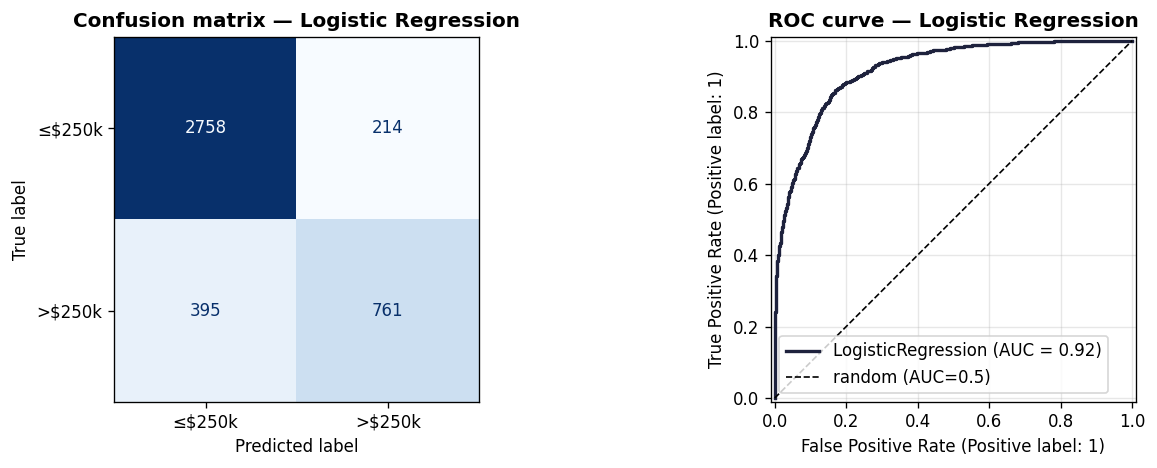

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    lr, X_test_s, y_test,
    display_labels=['≤$250k', '>$250k'],
    colorbar=False, ax=axes[0], cmap='Blues'
)
axes[0].set_title('Confusion matrix — Logistic Regression', fontsize=12, fontweight='bold')

# ROC curve
RocCurveDisplay.from_estimator(lr, X_test_s, y_test, ax=axes[1], color='#1E223D', linewidth=2)
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='random (AUC=0.5)')
axes[1].set_title('ROC curve — Logistic Regression', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.5 Feature importance

Because we standardised the features, the learned weights are directly comparable:  
a larger absolute value means stronger influence on the prediction.

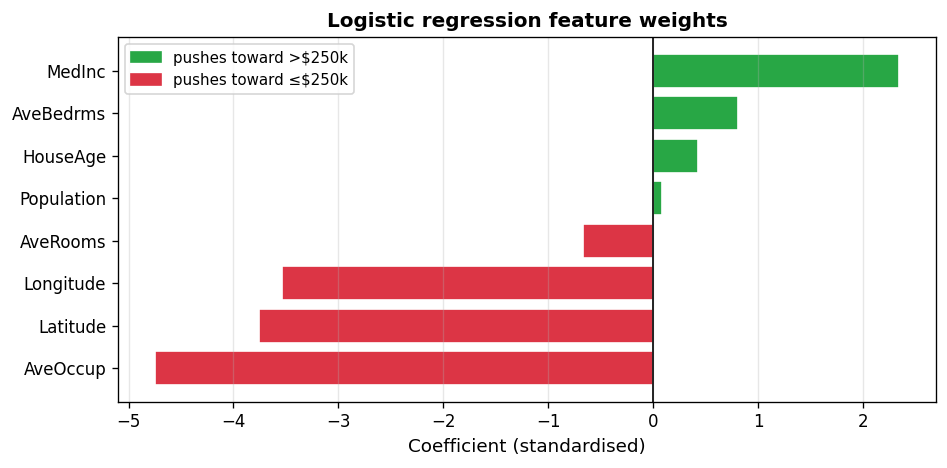

In [11]:
coef = pd.Series(lr.coef_[0], index=feature_names).sort_values()

colors = ['#dc3545' if v < 0 else '#28a745' for v in coef]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(coef.index, coef.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient (standardised)', fontsize=11)
ax.set_title('Logistic regression feature weights', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

green_patch = mpatches.Patch(color='#28a745', label='pushes toward >$250k')
red_patch   = mpatches.Patch(color='#dc3545', label='pushes toward ≤$250k')
ax.legend(handles=[green_patch, red_patch], fontsize=9)

plt.tight_layout()
plt.show()

---
## Part 3 — Introduction to Neural Networks

### 3.1 Activation functions

Without a non-linear activation, stacking layers is mathematically equivalent to a single layer. The activation is what gives neural networks their expressive power.

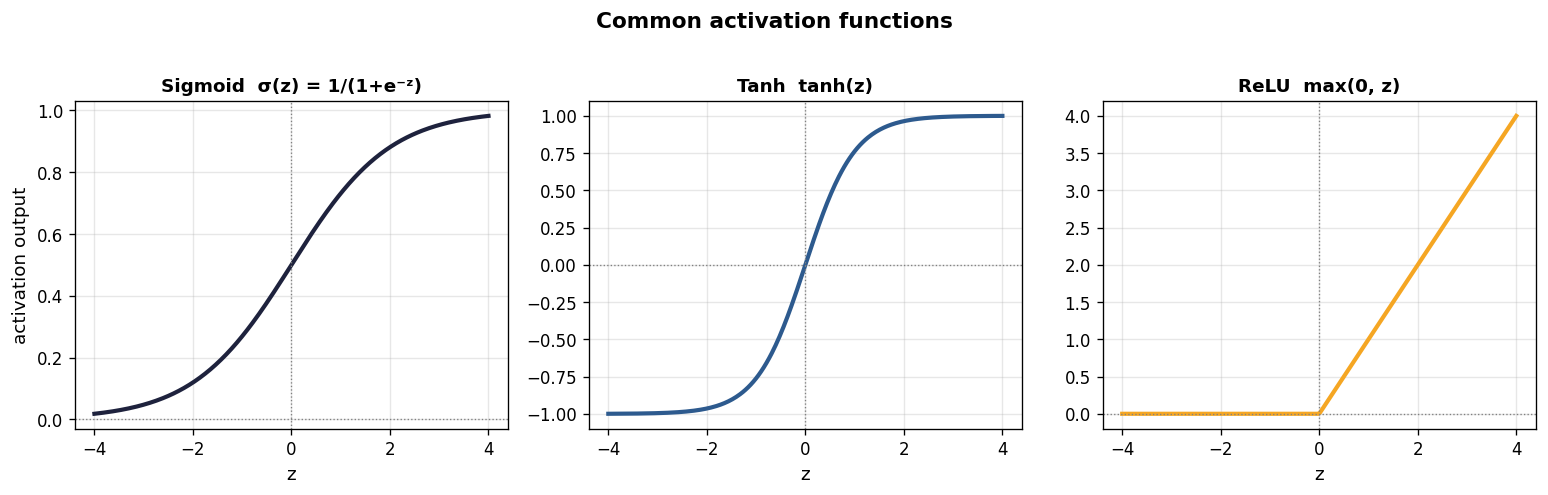

In [12]:
z = np.linspace(-4, 4, 300)

activations = {
    'Sigmoid  σ(z) = 1/(1+e⁻ᶻ)': (sigmoid(z), '#1E223D'),
    'Tanh  tanh(z)':               (np.tanh(z), '#2d5a8e'),
    'ReLU  max(0, z)':             (np.maximum(0, z), '#F5A623'),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, (name, (vals, color)) in zip(axes, activations.items()):
    ax.plot(z, vals, color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('z', fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('activation output', fontsize=11)
plt.suptitle('Common activation functions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 One hidden layer with PyTorch

Logistic regression is a network with **no hidden layers**.  
Adding one hidden layer with ReLU activations lets the model learn non-linear boundaries.

In [16]:
import torch
import torch.nn as nn

# Convert to tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32)

n_features = X_train_t.shape[1]
print(f'Input dimension: {n_features}')

# One hidden layer network
model_1h = nn.Sequential(
    nn.Linear(n_features, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

print('\nArchitecture:')
print(model_1h)
total_params = sum(p.numel() for p in model_1h.parameters())
print(f'\nTotal parameters: {total_params:,}')

Input dimension: 8

Architecture:
Sequential(
  (0): Linear(in_features=8, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
  (3): Sigmoid()
)

Total parameters: 161


### 3.3 The forward pass

A forward pass computes the prediction: features → hidden layer → sigmoid output.

In [17]:
# Single sample forward pass
sample = X_test_t[0].unsqueeze(0)   # shape: (1, 8)

with torch.no_grad():
    out = model_1h(sample)

print('Forward pass through the one-hidden-layer network:')
print(f'  Input shape:  {sample.shape}')
print(f'  Output:       {out.item():.4f}  (probability of class 1)')
print(f'  Prediction:   class {int(out.item() >= 0.5)}')
print(f'  True label:   class {int(y_test_t[0].item())}')

Forward pass through the one-hidden-layer network:
  Input shape:  torch.Size([1, 8])
  Output:       0.5482  (probability of class 1)
  Prediction:   class 1
  True label:   class 1


---
## Part 4 — Training Neural Networks

### 4.1 Deeper architecture

We add a second hidden layer for more expressive power.

In [23]:
class HousingClassifier(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model_2h = HousingClassifier(input_dim=n_features)
print('Architecture:')
print(model_2h)
total_params = sum(p.numel() for p in model_2h.parameters())
print(f'\nTotal parameters: {total_params:,}')

Architecture:
HousingClassifier(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 2,689


### 4.2 Training loop

Each iteration:
1. **Forward pass** — compute predictions and loss
2. **Backward pass** — compute gradients via backpropagation
3. **Gradient descent** — update weights with Adam optimiser

In [24]:
def train_model(model, X_tr, y_tr, X_val, y_val, epochs=100, lr=1e-3, batch_size=64):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    n = X_tr.shape[0]

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        # mini-batch training
        idx = torch.randperm(n)
        epoch_loss = 0
        for start in range(0, n, batch_size):
            batch_idx = idx[start:start+batch_size]
            X_b, y_b = X_tr[batch_idx], y_tr[batch_idx]
            optimizer.zero_grad()
            preds = model(X_b).squeeze()
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_idx)

        train_losses.append(epoch_loss / n)

        # validation
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val).squeeze()
            val_loss  = criterion(val_preds, y_val).item()
            val_acc   = ((val_preds >= 0.5).float() == y_val).float().mean().item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} | train loss: {train_losses[-1]:.4f} | '
                  f'val loss: {val_loss:.4f} | val acc: {val_acc:.4f}')

    return train_losses, val_losses, val_accs

print('Training 2-hidden-layer network...')
train_losses, val_losses, val_accs = train_model(
    model_2h, X_train_t, y_train_t, X_test_t, y_test_t, epochs=100, lr=1e-3
)

Training 2-hidden-layer network...
Epoch  20/100 | train loss: 0.2615 | val loss: 0.2571 | val acc: 0.8852
Epoch  40/100 | train loss: 0.2496 | val loss: 0.2486 | val acc: 0.8891
Epoch  60/100 | train loss: 0.2398 | val loss: 0.2429 | val acc: 0.8900
Epoch  80/100 | train loss: 0.2287 | val loss: 0.2446 | val acc: 0.8895
Epoch 100/100 | train loss: 0.2255 | val loss: 0.2367 | val acc: 0.8915


### 4.3 Learning curves

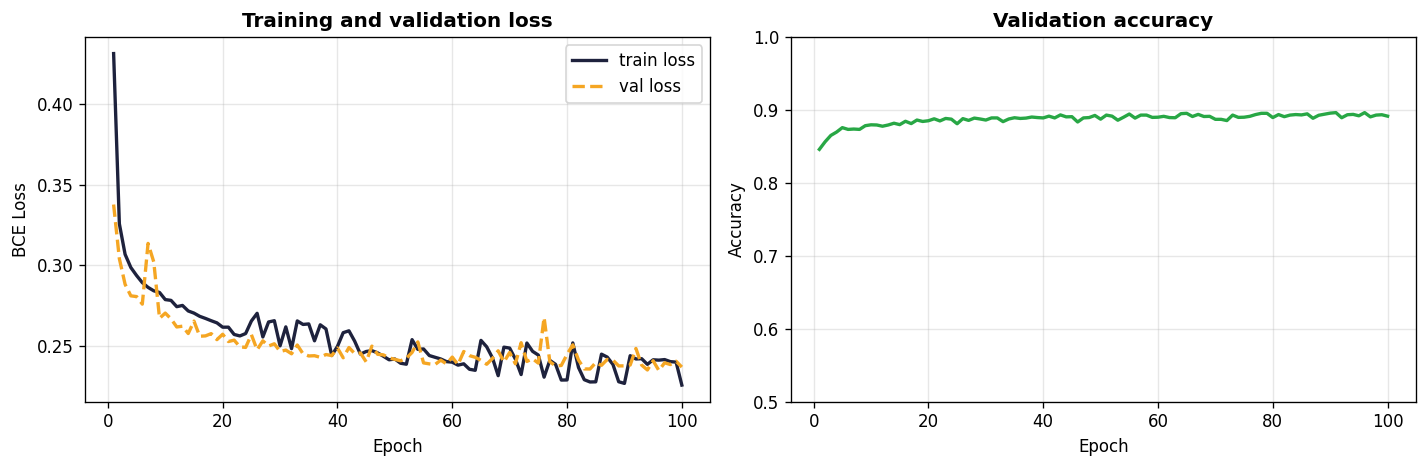

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label='train loss', color='#1E223D', linewidth=2)
axes[0].plot(epochs_range, val_losses,   label='val loss',   color='#F5A623', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training and validation loss', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
# axes[0].set_ylim(0.0, 0.5)

axes[1].plot(epochs_range, val_accs, color='#28a745', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation accuracy', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

### 4.4 Evaluate neural network

In [26]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score

model_2h.eval()
with torch.no_grad():
    nn_probs = model_2h(X_test_t).squeeze().numpy()

nn_preds = (nn_probs >= 0.5).astype(int)

print('Neural Network Classification Report:')
print(classification_report(y_test.values, nn_preds, target_names=['≤$250k', '>$250k']))
print(f'ROC-AUC: {roc_auc_score(y_test.values, nn_probs):.4f}')

Neural Network Classification Report:
              precision    recall  f1-score   support

      ≤$250k       0.92      0.93      0.93      2972
      >$250k       0.82      0.79      0.80      1156

    accuracy                           0.89      4128
   macro avg       0.87      0.86      0.86      4128
weighted avg       0.89      0.89      0.89      4128

ROC-AUC: 0.9561


### 4.5 Logistic regression vs neural network — head-to-head

           Logistic Regression  Neural Network (2 hidden)
Accuracy                0.8525                     0.8915
Precision               0.7805                     0.8195
Recall                  0.6583                     0.7855
F1                      0.7142                     0.8021
ROC-AUC                 0.9195                     0.9561


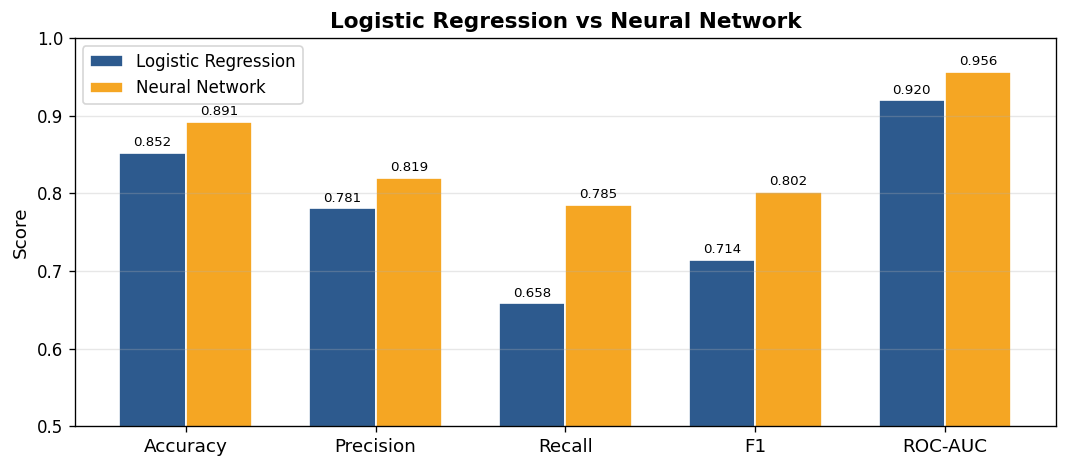

In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

def metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'ROC-AUC':   roc_auc_score(y_true, y_prob),
    }

lr_metrics = metrics(y_test.values, y_pred, y_prob)
nn_metrics = metrics(y_test.values, nn_preds, nn_probs)

results = pd.DataFrame({'Logistic Regression': lr_metrics,
                        'Neural Network (2 hidden)': nn_metrics})
print(results.round(4).to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(lr_metrics))
width = 0.35
bars1 = ax.bar(x - width/2, lr_metrics.values(), width, label='Logistic Regression', color='#2d5a8e', edgecolor='white')
bars2 = ax.bar(x + width/2, nn_metrics.values(),  width, label='Neural Network',      color='#F5A623', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(list(lr_metrics.keys()), fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_title('Logistic Regression vs Neural Network', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

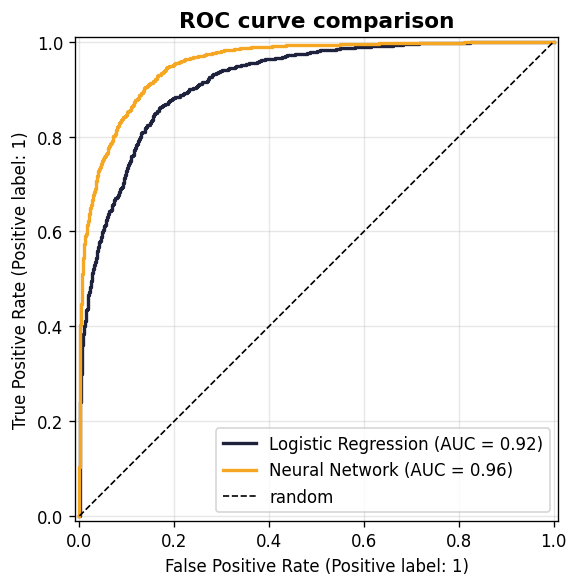

In [28]:
# ROC curve comparison
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(y_test.values, y_prob,    name='Logistic Regression', ax=ax, color='#1E223D', linewidth=2)
RocCurveDisplay.from_predictions(y_test.values, nn_probs,  name='Neural Network',      ax=ax, color='#F5A623', linewidth=2)
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='random')
ax.set_title('ROC curve comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 Effect of learning rate

The learning rate controls how large a step to take at each gradient update. Too large → oscillation. Too small → very slow convergence.

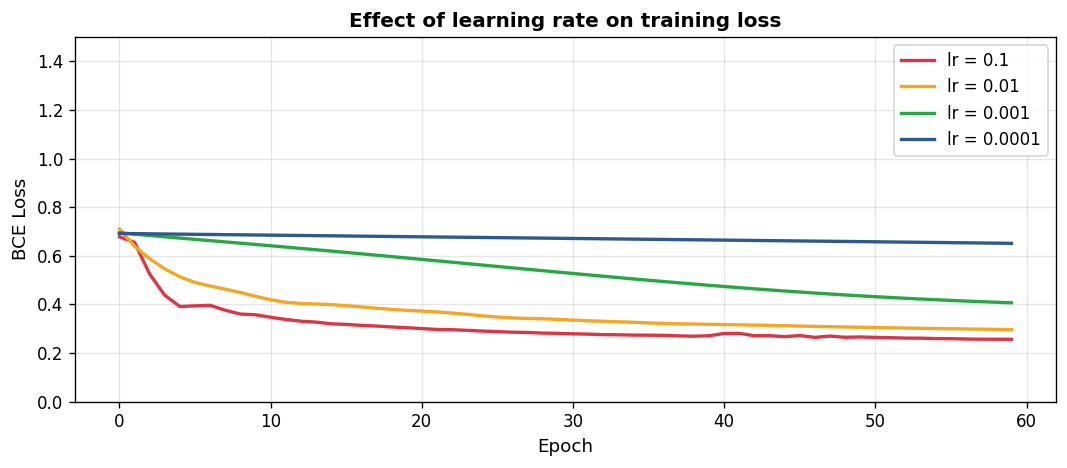

In [29]:
learning_rates = [1e-1, 1e-2, 1e-3, 1e-4]
colors_lr      = ['#dc3545', '#F5A623', '#28a745', '#2d5a8e']

fig, ax = plt.subplots(figsize=(9, 4))

for lr_val, color in zip(learning_rates, colors_lr):
    m = HousingClassifier(n_features)
    optimizer = torch.optim.Adam(m.parameters(), lr=lr_val)
    criterion = nn.BCELoss()
    losses = []
    for _ in range(60):
        m.train()
        optimizer.zero_grad()
        preds = m(X_train_t).squeeze()
        loss = criterion(preds, y_train_t)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    ax.plot(losses, label=f'lr = {lr_val}', color=color, linewidth=2)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('BCE Loss', fontsize=11)
ax.set_title('Effect of learning rate on training loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.5)
plt.tight_layout()
plt.show()

---
## Part 5 — Comparing to Tree-Based Models

Logistic regression and neural networks are not the only options.
**Random Forest** and **XGBoost** are tree-based ensembles that often outperform
simple neural networks on structured/tabular data — and require far less tuning.

### 5.1 Train Random Forest and XGBoost

Tree-based models do **not** require feature scaling — they are scale-invariant by design.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # unscaled — trees do not need scaling
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

# XGBoost
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                    use_label_encoder=False, eval_metric="logloss",
                    random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print("Random Forest trained.")
print("XGBoost trained.")

Random Forest trained.
XGBoost trained.


### 5.2 Metrics comparison across all four models

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "ROC-AUC":   roc_auc_score(y_true, y_prob),
    }

results = pd.DataFrame({
    "Logistic Reg.": get_metrics(y_test.values, y_pred,    y_prob),
    "Neural Net":    get_metrics(y_test.values, nn_preds,  nn_probs),
    "Random Forest": get_metrics(y_test.values, rf_preds,  rf_probs),
    "XGBoost":       get_metrics(y_test.values, xgb_preds, xgb_probs),
})

print(results.round(4).to_string())

           Logistic Reg.  Neural Net  Random Forest  XGBoost
Accuracy          0.8525      0.8915         0.9004   0.9109
Precision         0.7805      0.8195         0.8641   0.8537
Recall            0.6583      0.7855         0.7647   0.8227
F1                0.7142      0.8021         0.8114   0.8379
ROC-AUC           0.9195      0.9561         0.9614   0.9685


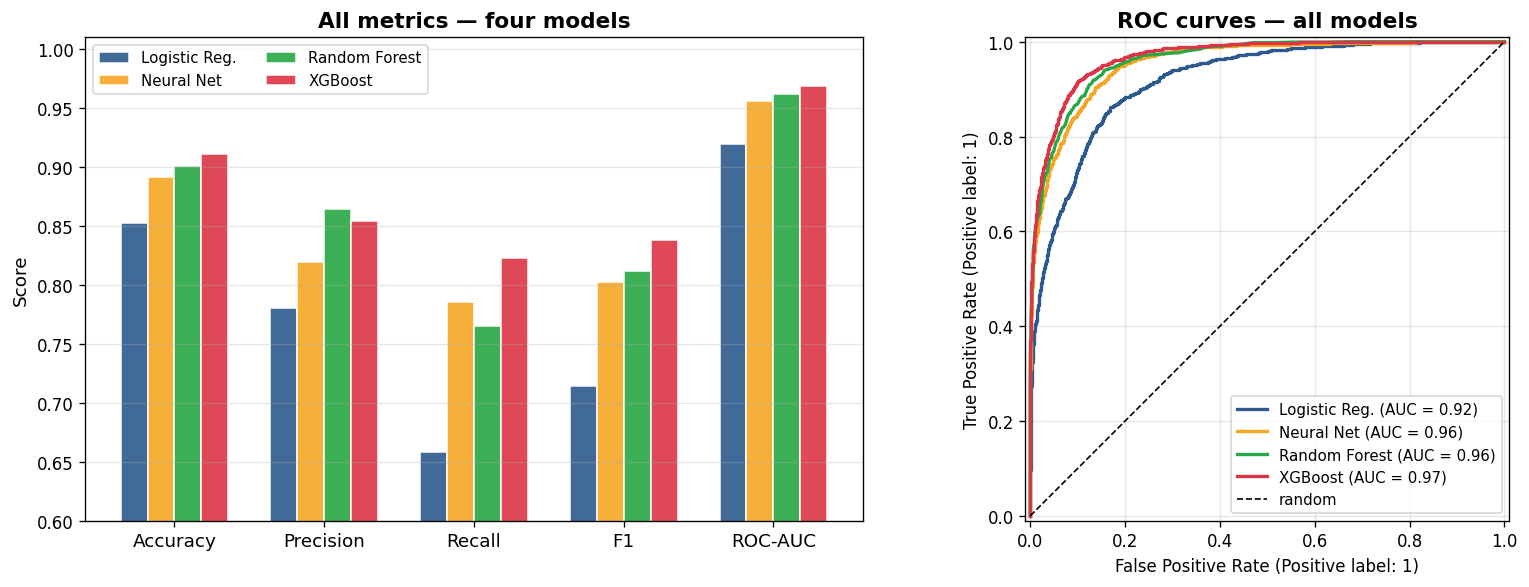

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart ---
model_names  = ["Logistic Reg.", "Neural Net", "Random Forest", "XGBoost"]
model_colors = ["#2d5a8e", "#F5A623", "#28a745", "#dc3545"]
metric_keys  = list(results.index)
x = np.arange(len(metric_keys))
width = 0.18

ax = axes[0]
for i, (name, color) in enumerate(zip(model_names, model_colors)):
    col_key = results.columns[i]
    bars = ax.bar(x + (i - 1.5) * width, results[col_key].values,
                  width, label=name, color=color,
                  edgecolor="white", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(metric_keys, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0.6, 1.01)
ax.set_title("All metrics — four models", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, axis="y")

# --- ROC curves ---
from sklearn.metrics import RocCurveDisplay
ax2 = axes[1]
for (col_key, y_p), color, name in zip(
        [("Logistic Reg.", y_prob), ("Neural Net", nn_probs),
         ("Random Forest", rf_probs), ("XGBoost", xgb_probs)],
        model_colors, ["Logistic Reg.", "Neural Net", "Random Forest", "XGBoost"]):
    RocCurveDisplay.from_predictions(
        y_test.values, y_p, name=name, ax=ax2, color=color, linewidth=2
    )
ax2.plot([0,1],[0,1], "k--", linewidth=1, label="random")
ax2.set_title("ROC curves — all models", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Feature importance — Random Forest vs XGBoost

Unlike logistic regression weights, tree-based importances measure
how much each feature reduces impurity (Random Forest) or the gain from splits (XGBoost).

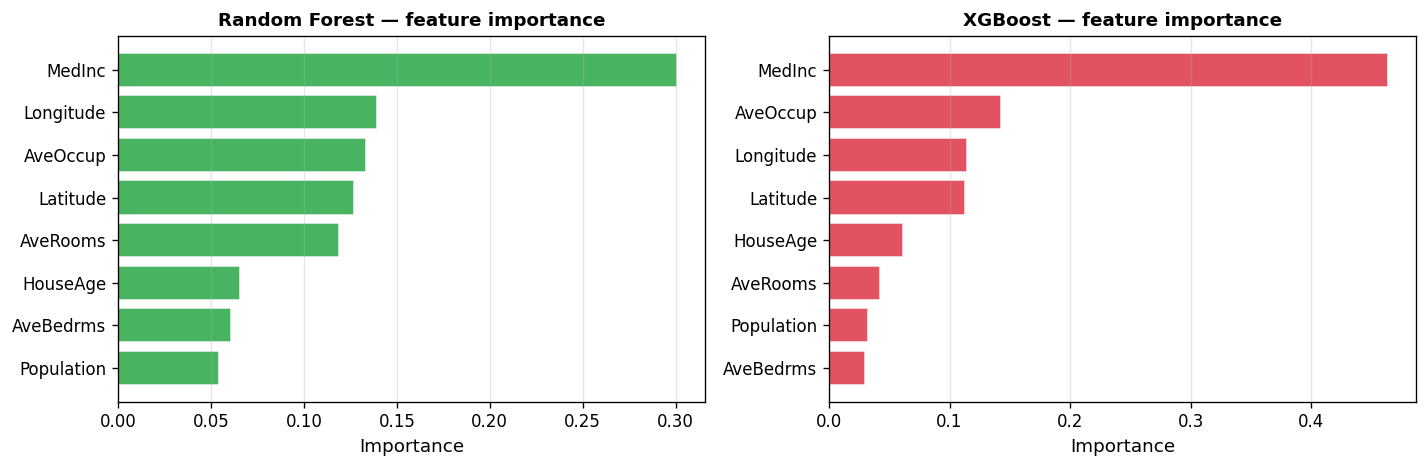

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, title, color in zip(
        axes,
        [rf, xgb],
        ["Random Forest — feature importance", "XGBoost — feature importance"],
        ["#28a745", "#dc3545"]):

    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values()
    ax.barh(imp.index, imp.values, color=color, edgecolor="white", alpha=0.85)
    ax.set_xlabel("Importance", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

### 5.4 Updated summary

| | Logistic Reg. | Neural Net | Random Forest | XGBoost |
|---|---|---|---|---|
| **Boundary** | Linear | Non-linear | Non-linear | Non-linear |
| **Feature scaling** | Required | Required | Not needed | Not needed |
| **Interpretability** | High | Low | Medium | Medium |
| **Tuning effort** | Minimal | High | Low | Medium |
| **Tabular data** | Good baseline | Competitive | Often best | Often best |

> **Rule of thumb for tabular data:** start with logistic regression (baseline), then try XGBoost.
> Neural networks are worth exploring when you have large datasets or want to integrate with deep learning pipelines.

## Bonus: Neural Network Classification on MNIST

MNIST is a classic multiclass classification dataset of handwritten digits (`0`-`9`).
The example below trains a small feed-forward neural network on flattened `28x28` grayscale images.

> To keep classroom runtime short, we train on a subset of MNIST rather than the full dataset.

Using device: cpu


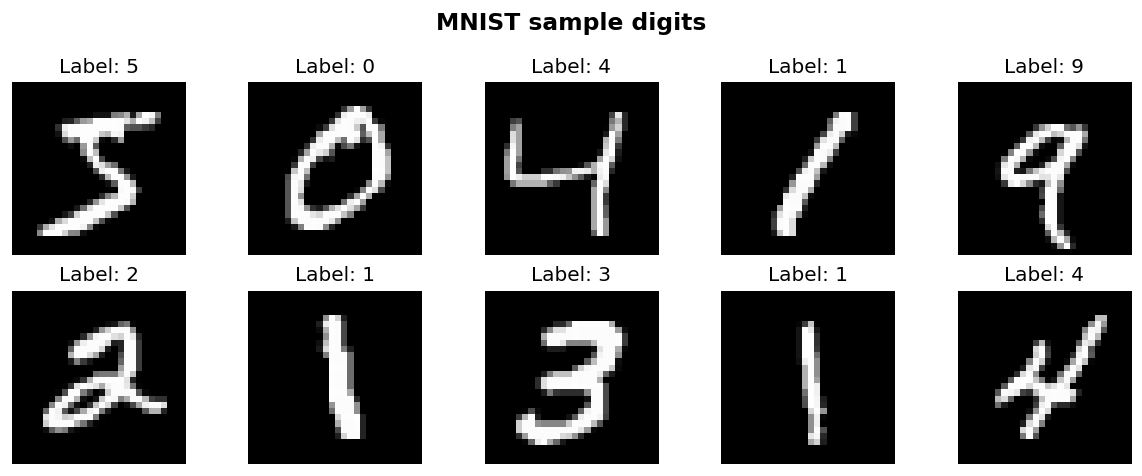

In [33]:
from torch import nn
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_full = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_dataset = Subset(train_full, range(10_000))
test_dataset = Subset(test_full, range(2_000))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    image, label = train_full[idx]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.suptitle("MNIST sample digits", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [31]:
data = Subset(train_full, range(10_000))
data[0][0].shape

torch.Size([1, 28, 28])

In [36]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

model = MNISTMLP().to(device)
print(model)


MNISTMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [37]:
mnist_model = MNISTMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mnist_model.parameters(), lr=1e-3)

epochs = 5
history = []

for epoch in range(epochs):
    mnist_model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = mnist_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        running_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    history.append((epoch_loss, epoch_acc))
    print(f"Epoch {epoch + 1}/{epochs} | loss={epoch_loss:.4f} | accuracy={epoch_acc:.4f}")

Epoch 1/5 | loss=0.7721 | accuracy=0.7855
Epoch 2/5 | loss=0.2893 | accuracy=0.9161
Epoch 3/5 | loss=0.2278 | accuracy=0.9314
Epoch 4/5 | loss=0.1788 | accuracy=0.9462
Epoch 5/5 | loss=0.1440 | accuracy=0.9582


Test accuracy: 0.9205
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       175
           1       0.96      0.98      0.97       234
           2       0.94      0.93      0.93       219
           3       0.89      0.96      0.92       207
           4       0.93      0.89      0.91       217
           5       0.97      0.85      0.91       179
           6       0.88      0.94      0.91       178
           7       0.92      0.88      0.90       205
           8       0.92      0.86      0.89       192
           9       0.86      0.93      0.89       194

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



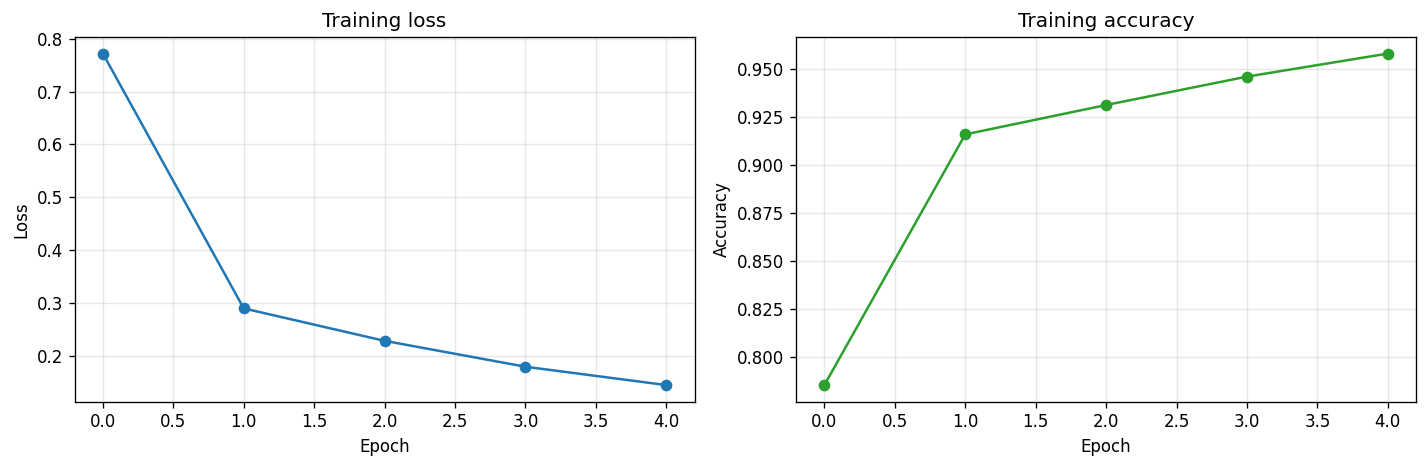

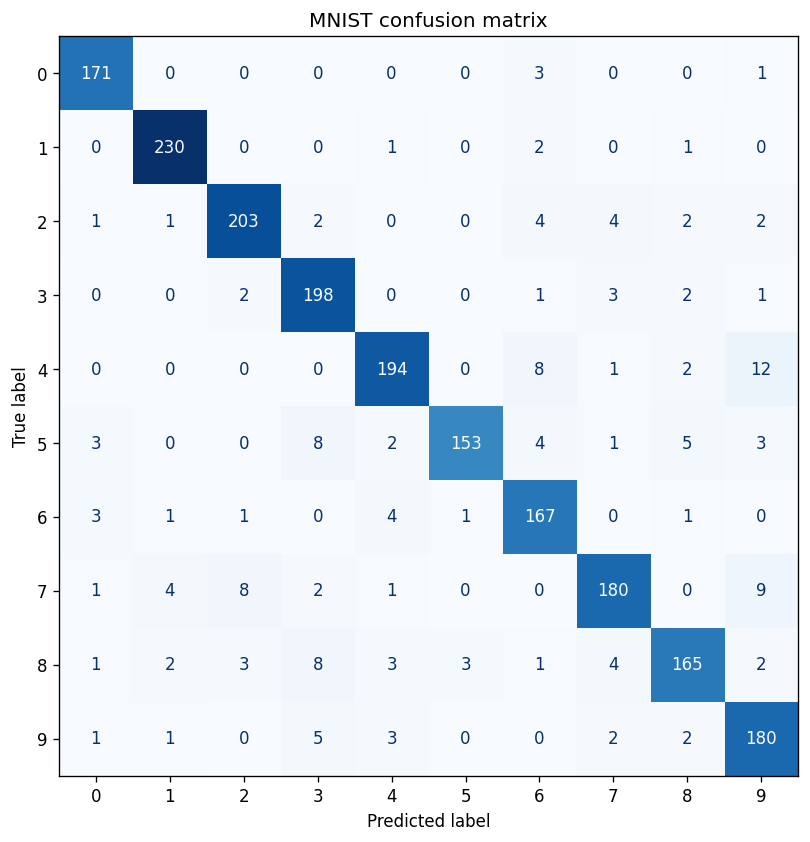

In [38]:
mnist_model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = mnist_model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)

test_accuracy = np.mean(np.array(y_true) == np.array(y_pred))
print(f"Test accuracy: {test_accuracy:.4f}")
print(classification_report(y_true, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot([loss for loss, _ in history], marker="o", label="Train loss")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot([acc for _, acc in history], marker="o", color="#2ca02c", label="Train accuracy")
axes[1].set_title("Training accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Blues", ax=ax, colorbar=False)
ax.set_title("MNIST confusion matrix")
plt.show()

## Homework Assignments

1. Optimize the neural network to achieve a better fit to the data.
2. Train a neural network to predict house prices as a regression problem.
3. (Advanced) Transform the problem into a multiclass classification task by dividing the target variable into more than two classes and compare the performance with the regression results.